# 4.45 Four Methods, One Full-Wave Model

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qiskit-community/qiskit-metal/blob/main/docs%2Ftut%2F4-Analysis%2F4.45-Four-methods-one-full-wave-model.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/qiskit-community/qiskit-metal/main?labpath=docs%2Ftut%2F4-Analysis%2F4.45-Four-methods-one-full-wave-model.ipynb)

> 💡 **What you need.** gmsh, scikit-fem and SciPy (`pip install "quantum-metal[mesh]" scikit-fem pymetis`). About 6 minutes and 10 GB of memory: the whole 10 × 10 package is meshed, because a junction on one qubit breaks the mirror symmetry. Last of five notebooks reproducing Molavi *et al.* [1]; [4.42](4.42-Four-ways-to-measure-a-coupling.ipynb) introduced the four methods on a circuit.

> 🧭 **Other simulation pathways.** This notebook uses the open-source gmsh + scikit-fem solver. The same quantities can come from Ansys HFSS / Q3D (tutorials 4.01–4.23) or, for capacitance, from the open-source ElmerFEM path for capacitance (tutorial 4.19); AWS Palace is planned. [Simulation pathways](https://qiskit-community.github.io/qiskit-metal/simulation-pathways.html) summarizes what each solver computes, how to install it, and which tutorials use it.

The paper's central result is its Fig. 7: four different ways of extracting the qubit–package coupling, run on the same 3D model, agree to within 5% for every qubit. This notebook reproduces that comparison with the open-source solver of notebooks 4.43 and 4.44.

The four methods differ only in what sits in the junction gap — an open circuit, a fixed inductor, a swept inductor, or a port with a shunt. In the edge-element formulation (notebook 4.43) a lumped element across a junction is one rank-one term, $(\mu_0/L)\,c\,c^T$, added to the stiffness matrix. The structure itself never changes. So the model is built once, as a *port reduced-order model*: its response at the 25 junctions of one quadrant plus a probe port, captured from one sparse factorization. Every method then runs on small dense matrices — the open-source equivalent of the fast frequency sweep in a commercial solver.

**What you'll learn**

- how to build a reduced model of a full-wave structure at its ports, and check it against direct solves;
- how the four methods look on a finite-element model: avoided crossing (the paper's Fig. 5), EPR, induced EMF and the impedance-matrix fit;
- how closely they agree across a quadrant of the array (Fig. 7), and where the small differences come from.

In [1]:
# In Colab, uncomment to install the dependencies of the whole series.
# !pip install -q "quantum-metal[mesh]" scikit-fem pymetis

In [2]:
import sys
import urllib.request
from pathlib import Path

# The solver code shared by tutorials 4.41-4.45 lives in docs/tut/resources/package_modes/.
RES = Path("../resources/package_modes")
if not (RES / "package_modes.py").exists():  # e.g. in Colab: fetch it next to the notebook
    RES = Path("package_modes")
    RES.mkdir(exist_ok=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/qiskit-community/qiskit-metal/main/"
        "docs/tut/resources/package_modes/package_modes.py", RES / "package_modes.py")
sys.path.insert(0, str(RES))

import package_modes as pm

import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize as opt
from matplotlib.colors import LogNorm

warnings.filterwarnings("ignore", category=FutureWarning)

MESH = dict(h_metal=0.1, h_max=1.0)  # mm; add h_junction=0.05 to seed the junctions more finely
P = pm.PAPER
TWO_PI = 2 * np.pi
design = pm.build_design()
package = pm.package_from_design(design)
QUADRANT = [f"Q_{i}_{j}" for j in range(5) for i in range(5)]  # the 25 qubits of the paper's Fig. 7

## 1. The full package and its port model

The mesh covers the whole box and all 100 qubits. It carries one extra port: a vertical wire from floor to lid, 0.5 mm from the wall at $y = L_y$ — across the box from the quadrant of qubits we compare, so that none of them sits next to it. The paper replaces a sidewall by a wave port to reach the package mode in its driven simulations; this probe does the same job for the impedance-matrix method. Left open it is invisible; shunted by a small inductance it is a thin post next to the wall.

`pm.PortROM` factors the finite-element matrix once at a shift near 6.35 GHz and builds a block Krylov space from the 26 port vectors. Projecting onto it matches the ports' frequency response around the shift to high order — every junction termination, every eigenfrequency, every impedance in the band follows from small dense matrices.

In [3]:
start = time.time()
mesh = pm.mesh_package(package, region="full", probe=(15.0, 29.5), **MESH)
fem = pm.MaxwellFEM(mesh)
print(f"{mesh.summary()}\n{fem.n_dofs:,} unknowns, assembled in {fem.assembly_time:.0f} s")
rom = pm.PortROM(fem, QUADRANT + ["probe"], f_center=6.35e9, n_moments=4)
fem._factors.clear()  # the reduced model holds everything the methods need

full package: 438,045 tetrahedra, 81,305 nodes, 200 paddles, 100 junctions, 1 probe (meshed in 3.9 s)
455,656 unknowns, assembled in 15 s


port ROM: 26 ports, 104 basis vectors, built in 48 s


## 2. The capacitance this model sees

The induced-EMF method needs the capacitance across each junction. Notebook 4.43 computed it with second-order electrostatics: 174 fF. But a fair comparison of methods puts all four on the *same* discrete model, and this model's qubits are slightly different. Lowest-order edge elements contain the gradients of first-order nodal functions exactly, so the static fields of the Maxwell model — including each qubit's charge configuration — are those of *first-order* electrostatics on the same mesh. On a coarse mesh that capacitance comes out larger, because the charge that crowds onto the paddle edges is poorly resolved. `pm.Electrostatics(mesh, order=1)` computes exactly the capacitance the Maxwell model sees.

In [4]:
start = time.time()
es1 = pm.Electrostatics(mesh, order=1)
C_port = {q: es1.port_capacitance(f"{q}.pad_left", f"{q}.pad_right") for q in QUADRANT}
del es1
print(f"capacitance across the junction seen by this mesh: {min(C_port.values()) * 1e15:.0f} - "
      f"{max(C_port.values()) * 1e15:.0f} fF  ({time.time() - start:.0f} s)")
print("converged value (notebook 4.43, second-order electrostatics on a finer mesh): 174 fF")

capacitance across the junction seen by this mesh: 228 - 237 fF  (14 s)
converged value (notebook 4.43, second-order electrostatics on a finer mesh): 174 fF


Trust, but verify: one direct eigensolve of the full model, with every junction open, against the reduced model.

In [5]:
start = time.time()
(direct,) = fem.eigenmodes(6.5e9)
f_rom, V_rom = rom.eigenmodes(fmin=6e9, fmax=7e9)
k = rom._index("Q_1_1")
sign = np.sign(V_rom[0, k] * direct.voltage("Q_1_1"))
print(f"package mode: direct {direct.f / 1e9:.6f} GHz, reduced {f_rom[0] / 1e9:.6f} GHz")
print(f"voltage across the open junction of Q_1_1: direct {direct.voltage('Q_1_1'):.2f} V,"
      f" reduced {sign * V_rom[0, k]:.2f} V   ({time.time() - start:.0f} s)")
del direct

package mode: direct 6.486131 GHz, reduced 6.486131 GHz
voltage across the open junction of Q_1_1: direct -6373.92 V, reduced -6373.92 V   (20 s)


## 3. Induced EMF

All junctions open, one mode, 25 voltages, Eq. (11), with the capacitance of Sec. 2:

In [6]:
f_m = f_rom[0]
V_open = sign * V_rom[0]
g_emf = {q: pm.emf_coupling(f_m, V_open[rom._index(q)], C_port[q]) for q in QUADRANT}
print("g_EMF/2pi (MHz):", ", ".join(f"{q[2:]} {g / 1e6:+.2f}" for q, g in list(g_emf.items())[:6]), "...")

g_EMF/2pi (MHz): 0_0 -2.68, 1_0 -2.41, 2_0 -2.12, 3_0 -1.16, 4_0 -0.26, 0_1 -7.89 ...


## 4. Avoided crossing (Fig. 5)

Put an inductor $L_{\rm qubit}$ across one junction, leave the rest open, and sweep it. In the reduced model each value of $L_{\rm qubit}$ is a dense eigenproblem of a hundred-odd unknowns — milliseconds. For qubit (1,1), the paper's example:

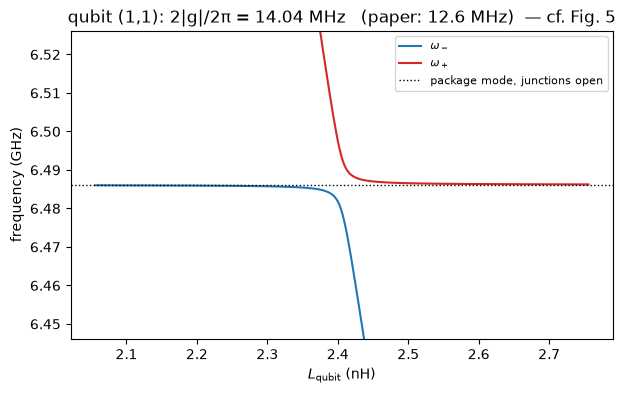

In [7]:
def two_modes(q, L):
    """The two eigenfrequencies nearest the package mode with inductor L on junction q."""
    f, V = rom.eigenmodes(inductors={q: L}, fmin=1e9, fmax=12e9)
    k = np.argsort(np.abs(f - f_m))[:2]
    return np.sort(f[k])


def splitting(L, q):
    f = two_modes(q, L)
    return f[1] - f[0]


def min_splitting(q):
    """Scan, then refine: the inductance where the two branches come closest."""
    grid = np.linspace(1.5e-9, 4.5e-9, 61)
    k = np.argmin([splitting(L, q) for L in grid])
    return opt.minimize_scalar(splitting, bounds=(grid[max(k - 1, 0)], grid[min(k + 1, 60)]), args=(q,),
                               method="bounded", options=dict(xatol=1e-16))


res = min_splitting("Q_1_1")
two_g = res.fun
Ls = np.linspace(res.x - 0.35e-9, res.x + 0.35e-9, 300)
branches = np.array([two_modes("Q_1_1", L) for L in Ls])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(Ls * 1e9, branches[:, 0] / 1e9, color="tab:blue", label=r"$\omega_-$")
ax.plot(Ls * 1e9, branches[:, 1] / 1e9, color="tab:red", label=r"$\omega_+$")
ax.axhline(f_m / 1e9, color="k", ls=":", lw=1, label="package mode, junctions open")
ax.set(xlabel=r"$L_{\rm qubit}$ (nH)", ylabel="frequency (GHz)", ylim=(f_m / 1e9 - 0.04, f_m / 1e9 + 0.04),
       title=f"qubit (1,1): 2|g|/2π = {two_g / 1e6:.2f} MHz   (paper: {P['two_g_q11'] / 1e6:.1f} MHz)  — cf. Fig. 5")
ax.legend(fontsize=8)
plt.show()

What do the two modes look like at the bottom of the anticrossing? `rom.modes` returns full finite-element fields from the reduced model. Next to the package mode with every junction open, the two hybrid modes both carry the package field *and* the qubit's own dipole field around qubit (1,1) — one excitation shared between the qubit and the box. The color scale is logarithmic: near its paddles the qubit's field is a hundred times the package field.

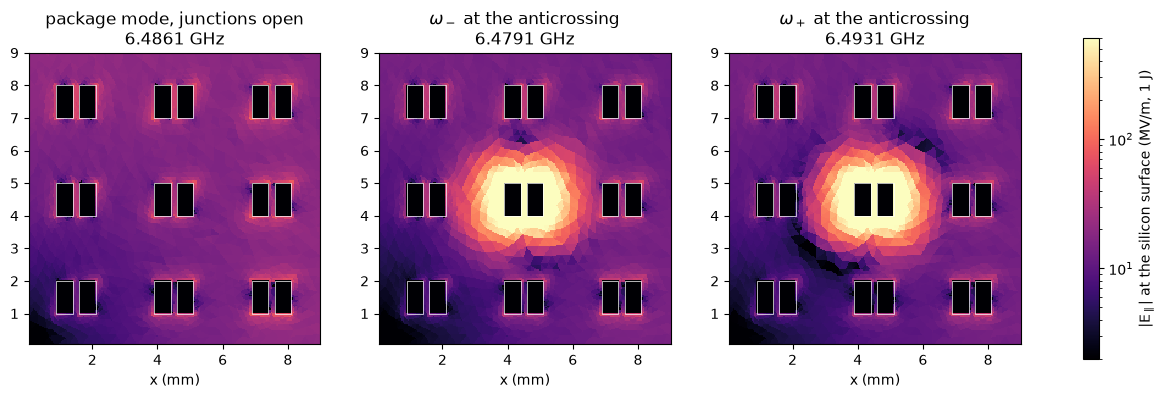

In [8]:
L_star = res.x
open_mode = rom.modes(fmin=f_m - 1e6, fmax=f_m + 1e6)[0]
hybrids = rom.modes(inductors={"Q_1_1": L_star}, fmin=f_m - 0.05e9, fmax=f_m + 0.05e9)
zx, zy = np.meshgrid(np.linspace(0.05, 9, 240), np.linspace(0.05, 9, 240))
pts = np.vstack([zx.ravel(), zy.ravel(), np.full(zx.size, package.t + 1e-6)])

fig, ax = plt.subplots(1, 3, figsize=(16, 5.2))
for a, m, title in zip(ax, [open_mode] + hybrids,
                       ["package mode, junctions open", r"$\omega_-$ at the anticrossing", r"$\omega_+$ at the anticrossing"]):
    E = m.field(pts)
    mag = np.hypot(E[0], E[1]).reshape(zx.shape) / 1e6
    im = a.pcolormesh(zx, zy, mag, cmap="magma", norm=LogNorm(vmin=2, vmax=600), shading="auto")
    for poly in package.metals.values():
        a.fill(poly[:, 0], poly[:, 1], facecolor="none", edgecolor="w", lw=0.5)
    a.set(xlim=(0.05, 9), ylim=(0.05, 9), aspect="equal", xlabel="x (mm)",
          title=f"{title}\n{m.f / 1e9:.4f} GHz")
plt.colorbar(im, ax=ax, shrink=0.8, label="|E$_\parallel$| at the silicon surface (MV/m, 1 J)")
plt.show()

On this coarse full-box mesh the splitting comes out larger than the paper's 12.6 MHz: the qubits of this discrete model carry the larger capacitance of Sec. 2. The converged induced-EMF couplings of notebook 4.44, $|A|/2\pi \approx$ 15.6 MHz, give $2|g|/2\pi = 2|A|\cos(0.15\pi)\sin(0.15\pi) \approx$ 12.6 MHz for this qubit — the paper's value.

The same minimization, automated over the quadrant:

In [9]:
start = time.time()
g_ac = {}
for q in QUADRANT:
    g_ac[q] = min_splitting(q).fun / 2 * np.sign(g_emf[q])  # the splitting gives |g|; the sign is copied for plotting
print(f"25 avoided crossings in {time.time() - start:.0f} s")

25 avoided crossings in 42 s


## 5. Energy participation

Fix the inductor so the qubit sits about 0.23 GHz below the package mode (the paper uses 6.25 GHz), solve for the package-like mode, and read the voltage across the inductor. With the mode normalized to $E_m$ = 1 J, Eq. (9) and Eq. (10) give

$$g = \frac{\omega_m^2-\omega_n^2}{2\sqrt{\omega_m\omega_n}}\;\frac{V_{n}}{\omega_m\sqrt{2E_mL_{\rm qubit}}}\;\sqrt{\frac{\omega_m}{\omega_n}} ,$$

with $\omega_n$ the qubit-like mode of the same solve. The sign of $V_n$ is the sign of $g$.

In [10]:
F_QUBIT = 6.25e9


def qubit_frequency(q, L):
    """Frequency of the qubit-like mode: the one with the largest junction voltage relative to the probe."""
    f, V = rom.eigenmodes(inductors={q: L}, fmin=1e9, fmax=12e9)
    ratio = np.abs(V[:, rom._index(q)]) / np.abs(V[:, rom._index("probe")])
    return f[np.argmax(ratio)]


def inductance_for(q, f_target):
    """The junction inductance that puts qubit q's mode at f_target."""
    return opt.brentq(lambda L: qubit_frequency(q, L) - f_target, 1.0e-9, 8.0e-9, xtol=1e-16)


def epr(q):
    L = inductance_for(q, F_QUBIT)
    f, V = rom.eigenmodes(inductors={q: L}, fmin=1e9, fmax=12e9)
    m = np.argmin(np.abs(f - f_m))  # the package-like mode
    n = np.argmin(np.abs(f - F_QUBIT))  # the qubit-like mode
    wm, wn = TWO_PI * f[m], TWO_PI * f[n]
    Vq = V[m, rom._index(q)] * sign
    lhs = (wm**2 - wn**2) / (2 * np.sqrt(wm * wn)) * Vq / (wm * np.sqrt(2 * 1.0 * L))
    return lhs * np.sqrt(wm / wn) / TWO_PI, L


start = time.time()
g_epr, L_epr = {}, {}
for q in QUADRANT:
    g_epr[q], L_epr[q] = epr(q)
print(f"L_qubit = {min(L_epr.values()) * 1e9:.3f} - {max(L_epr.values()) * 1e9:.3f} nH;"
      f" 25 EPR extractions in {time.time() - start:.0f} s")

L_qubit = 2.542 - 2.639 nH; 25 EPR extractions in 5 s


## 6. Impedance matrix

Shunt the junction of one qubit and the probe, leave the other qubits open, and compute the 2 × 2 impedance matrix from 6 to 7 GHz with 0.1 MHz resolution, as in the paper — refined around the two poles, because for a weakly coupled qubit the package pole sits within a kHz of a zero. The reduced model knows where the poles are, and evaluating it on a fine grid costs nothing: an adaptive frequency sweep. The paper's 3.6 nH shunt put its qubit 0.39 GHz below the package mode; our qubit has a larger capacitance on this mesh (Sec. 2), so the shunt is chosen for the same detuning. The paper shunts its wall port with 1 pH; our probe reaches the package mode more weakly than a whole wall, and with 1 pH its pole and the zero beside it fall within one 0.1 MHz step, so it gets 0.1 nH. Then fit with the procedure of Appendix D (notebook 4.42) and compute $g$ from the fitted circuit.

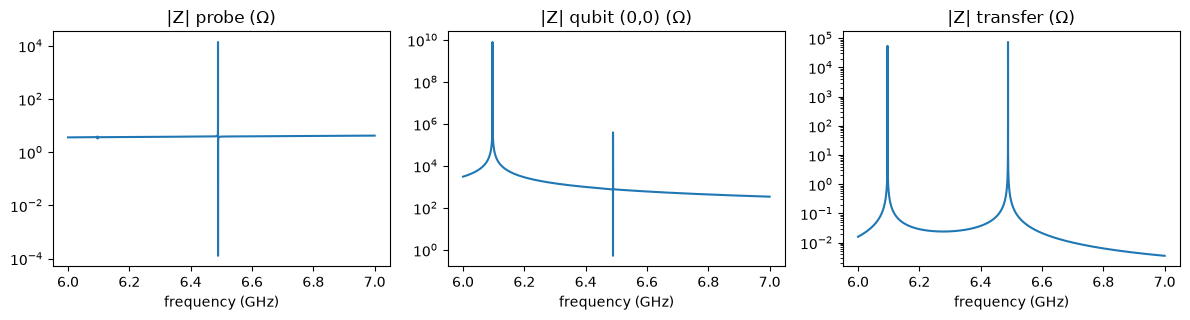

shunt 2.74 nH; poles [6.09613078 6.48907592] GHz, relative misfit 9.7e-05
            this fit    paper
 L'_n (nH)     2.738    3.630
  C_n (fF)   231.133  173.800
dL'_n (nH)     0.211    0.320
g/2pi (MHz)     2.680    2.420


In [11]:
L_PROBE = 0.1e-9  # probe shunt


def impedance_fit(q):
    L = inductance_for(q, f_m - 0.39e9)
    shunts = {q: L, "probe": L_PROBE}
    # 0.1 MHz steps from 6 to 7 GHz, as in the paper, refined to 0.1 kHz around the two poles:
    # the reduced model knows where they are, as an adaptive frequency sweep would
    poles, _ = rom.eigenmodes(inductors=shunts, fmin=6e9, fmax=7e9)
    fine = [np.linspace(p - 0.2e6, p + 0.2e6, 4001) + 37.3 for p in poles]  # 100 Hz steps, offset so none lands on a pole
    f = np.union1d(np.linspace(6.0e9, 7.0e9, 10001), np.concatenate(fine))
    Z = rom.impedance(f, inductors=shunts, ports=["probe", q])
    return pm.fit_impedance(TWO_PI * f, Z), Z, L, f


fit00, Z00, L00, f_grid = impedance_fit("Q_0_0")
fig, ax = plt.subplots(1, 3, figsize=(12, 3.3), sharex=True)
for a, (r, c_), name in zip(ax, ((0, 0), (1, 1), (0, 1)), ("probe", "qubit (0,0)", "transfer")):
    a.semilogy(f_grid / 1e9, np.abs(Z00[:, r, c_]))
    a.set(title=f"|Z| {name} (Ω)", xlabel="frequency (GHz)")
plt.tight_layout()
plt.show()

gC, gL, g00 = fit00.couplings()
print(f"shunt {L00 * 1e9:.2f} nH; poles {fit00.poles / TWO_PI / 1e9} GHz, relative misfit {fit00.rms_error:.1e}")
print(f"{'':>10} {'this fit':>9} {'paper':>8}")
for name, ours, theirs, s in (("L'_n (nH)", fit00.Lp[1, 1], P["zfit_q00"]["Lp_n"], 1e9),
                              ("C_n (fF)", fit00.C[1, 1] + fit00.C[0, 1], P["zfit_q00"]["C_n"], 1e15),
                              ("dL'_n (nH)", fit00.dL[1, 1], P["zfit_q00"]["dL_n"], 1e9),
                              ("g/2pi (MHz)", abs(g00), P["zfit_q00"]["g"], 1e-6)):
    print(f"{name:>10} {ours * s:9.3f} {theirs * s:8.3f}")

The fit returns the shunt we put in, and the qubit's capacitance and geometric inductance as *this* model has them: the capacitance of Sec. 2 rather than the converged 174 fF, and a geometric inductance of a few tenths of a nH, like the paper's 0.32 nH. The package side of the circuit need not match the paper at all: our probe is not the paper's wave port, and a different port reaches the same distributed mode through different $C_c$, $M$ and $\delta L'_m$ (the paper's own warning about separating $g_C$ from $g_L$). Only $g$ is port-independent. Now the quadrant:

In [12]:
start = time.time()
g_z = {}
for q in QUADRANT:
    fit, _, _, _ = impedance_fit(q)
    g_z[q] = fit.couplings()[2]
print(f"25 impedance fits in {time.time() - start:.0f} s")

25 impedance fits in 16 s


## 7. Side by side (Fig. 7)

The qubits are numbered 1 to 25 row by row from the corner, (0,0) = 1, (4,0) = 5, (0,1) = 6, and so on. The sign convention is that of the induced EMF; the avoided crossing gives magnitudes only.

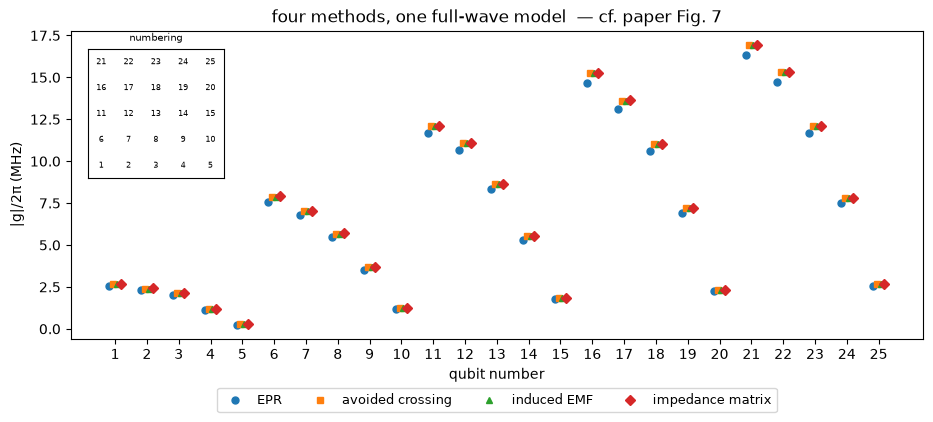

largest relative difference between methods: 4.1%  (paper: 4.8%)
EPR below the other three by 3.7% on average; counting only the junction's share of the qubit inductance predicts 3.6% (notebook 4.42)
average relative difference: 3.8%  (paper: 2.9%)
              EPR: mean ratio to the four-method average 0.972
 avoided crossing: mean ratio to the four-method average 1.009
      induced EMF: mean ratio to the four-method average 1.009
 impedance matrix: mean ratio to the four-method average 1.010


In [13]:
methods = {"EPR": g_epr, "avoided crossing": g_ac, "induced EMF": g_emf, "impedance matrix": g_z}
G = np.array([[abs(methods[m][q]) for q in QUADRANT] for m in methods])  # (4, 25), Hz
number = np.arange(1, 26)

fig, ax = plt.subplots(figsize=(11, 4))
for k, (name, marker) in enumerate(zip(methods, "os^D")):
    ax.plot(number + (k - 1.5) * 0.12, G[k] / 1e6, marker, ms=5, label=name)
ax.set(xlabel="qubit number", ylabel="|g|/2π (MHz)", xticks=number,
       title="four methods, one full-wave model  — cf. paper Fig. 7")
ax.legend(ncol=4, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.14))
inset = ax.inset_axes([0.02, 0.52, 0.16, 0.42])
for q, nmb in zip(QUADRANT, number):
    i, j = pm.Package.qubit_index(q)
    inset.text(i, j, str(nmb), ha="center", va="center", fontsize=6)
inset.set(xlim=(-0.5, 4.5), ylim=(-0.5, 4.5), xticks=[], yticks=[])
inset.set_title("numbering", fontsize=7)
plt.show()

spread = (G.max(axis=0) - G.min(axis=0)) / G.mean(axis=0)
print(f"largest relative difference between methods: {spread.max():.1%}  (paper: {P['max_rel_diff']:.1%})")
ratio_epr = np.mean(G[0] / G[1:].mean(axis=0))
print(f"EPR below the other three by {1 - ratio_epr:.1%} on average; counting only the junction's share of the"
      f" qubit inductance predicts {1 - np.sqrt(L00 / (L00 + fit00.dL[1, 1])):.1%} (notebook 4.42)")
print(f"average relative difference: {spread.mean():.1%}  (paper: 2.9%)")
for name, row in zip(methods, G):
    print(f"{name:>17}: mean ratio to the four-method average {np.mean(row / G.mean(axis=0)):.3f}")

The same data as maps of the quadrant, one per method, on a common color scale, and the spread between methods qubit by qubit:

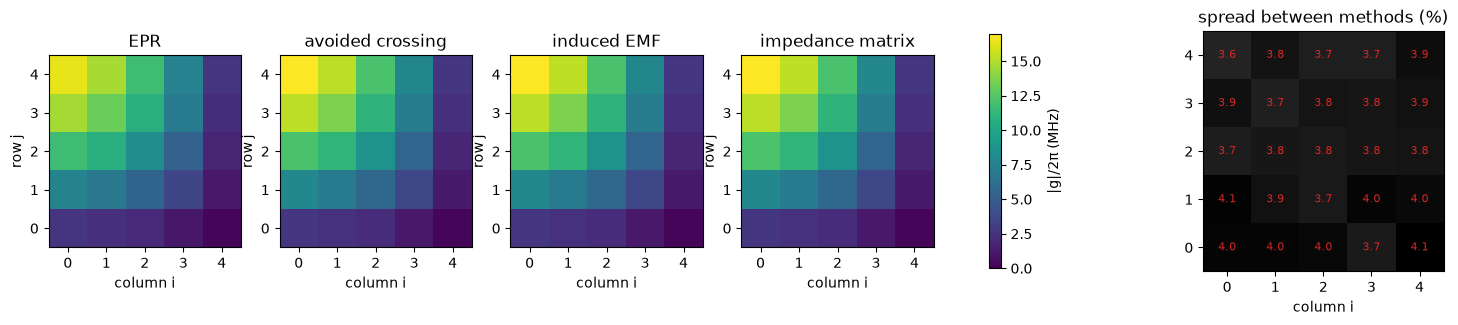

In [14]:
fig, ax = plt.subplots(1, 5, figsize=(18, 3.8))
vmax = G.max() / 1e6
for a, name, row in zip(ax, methods, G):
    im = a.imshow(row.reshape(5, 5) / 1e6, origin="lower", cmap="viridis", vmin=0, vmax=vmax)
    a.set(title=name, xlabel="column i", ylabel="row j", xticks=range(5), yticks=range(5))
plt.colorbar(im, ax=ax[:4], shrink=0.8, label="|g|/2π (MHz)")
im = ax[4].imshow(spread.reshape(5, 5) * 100, origin="lower", cmap="Greys", vmin=0)
for k, v in enumerate(spread):
    ax[4].text(k % 5, k // 5, f"{v * 100:.1f}", ha="center", va="center", fontsize=8, color="tab:red")
ax[4].set(title="spread between methods (%)", xlabel="column i", xticks=range(5), yticks=range(5))
plt.show()

## What this tells you

- **They agree.** Four simulations that put four different things in the junction — nothing, a fixed inductor, a swept inductor, a port — return the same coupling for every qubit, within a few percent. The choice of method is a matter of convenience, as the paper concludes.
- **Agreement is not convergence.** All four run on the same coarse full-box mesh and share its discretization error; the converged couplings are those of notebook 4.44 (|A|/2π ≈ 15.6 MHz). Refining the paddle edges moves all four together.
- **The spread has a structure.** EPR sits lowest, as in the paper, and by the amount notebook 4.42 predicts: Eq. (8) counts only the junction's share of the qubit's inductance and leaves out the geometric inductance of the paddles — here part of the field around the junction, a few tenths of a nH according to the impedance fit.
- **Cost decides.** The induced EMF needs one eigenmode for all qubits and one capacitance per qubit. EPR and the avoided crossing need a solve per qubit (per inductance, for the crossing); the impedance matrix needs a driven sweep and a fit per qubit. Here the reduced model makes the extra solves nearly free — a direct approach would need 25 separate factorizations for EPR alone.

## Where to go next

- **Tighten the mesh** around the junctions (`h_junction=0.05` in `MESH`) and watch all four methods move together — the agreement between methods is not a substitute for convergence (notebook 4.44, Sec. 4).
- **Qubit–qubit couplings.** The same port model holds all 25 junctions: put inductors on two neighboring qubits and look for their avoided crossing — the paper notes the methods apply to qubit–qubit couplings unchanged.
- **A real processor** adds a ground plane, readout resonators and couplers; each is more geometry for the same mesher and solver, and more ports for the same reduced model.

## References

1. R. Molavi, E. Forati, Y. Zhang, A. R. Klots, J. Atalaya, B. W. Langley, D. A. Timucin, M. Nazari, G. Khan, Z. K. Minev, A. N. Korotkov, M. H. Devoret, "Extracting electromagnetic bare mode couplings in large superconducting quantum processors," [arXiv:2609.22442](https://arxiv.org/abs/2609.22442) (2026).
2. Z. K. Minev, Z. Leghtas, S. O. Mundhada, L. Christakis, I. M. Pop, M. H. Devoret, "Energy-participation quantization of Josephson circuits," *npj Quantum Inf.* **7**, 131 (2021). [doi:10.1038/s41534-021-00461-8](https://doi.org/10.1038/s41534-021-00461-8)
3. C. A. Balanis, *Advanced Engineering Electromagnetics*, 2nd ed. (Wiley, 2012) — LSM modes of a partially filled waveguide.
4. C. Geuzaine, J.-F. Remacle, "Gmsh: A 3-D finite element mesh generator with built-in pre- and post-processing facilities," *Int. J. Numer. Methods Eng.* **79**, 1309–1331 (2009). [doi:10.1002/nme.2579](https://doi.org/10.1002/nme.2579)
5. T. Gustafsson, G. D. McBain, "scikit-fem: A Python package for finite element assembly," *J. Open Source Softw.* **5**, 2369 (2020). [doi:10.21105/joss.02369](https://doi.org/10.21105/joss.02369)